Esta sección del libro de Aurélien Géron es fundamental, ya que revela la matemática y la teoría computacional que ocurren "bajo el capó" cuando ejecutas el método `.fit()` en Scikit-Learn. 

Explica por qué los árboles se construyen de la forma en que lo hacen y por qué la informática debe conformarse con soluciones "buenas" en lugar de "perfectas".



A continuación, tienes la **traducción técnica**, las **correcciones y actualizaciones matemáticas**, y los **scripts de Python** para que veas en la práctica cómo funciona esta función de costo.

---



## 1. Traducción, Corrección y Actualización del Texto



### El Algoritmo de Entrenamiento CART

Scikit-Learn utiliza el algoritmo de Árboles de Clasificación y Regresión (**CART**, por sus siglas en inglés: *Classification and Regression Trees*) para entrenar árboles de decisión (proceso también conocido como "hacer crecer" el árbol).



El algoritmo funciona dividiendo primero el conjunto de datos de entrenamiento en dos subconjuntos utilizando una sola característica $k$ y un umbral $t_k$ (por ejemplo, "longitud del pétalo $\le$ 2.45 cm"). 

¿Cómo elige $k$ y $t_k$? Busca el par $(k, t_k)$ que produzca los subconjuntos más puros, ponderados por su tamaño. 

La Ecuación 5-2 muestra la **función de costo** que el algoritmo intenta minimizar.



## Ecuación 5-2. Función de costo CART para clasificación

$$J(k, t_k) = \frac{m_{\text{izq}}}{m} G_{\text{izq}} + \frac{m_{\text{der}}}{m} G_{\text{der}}$$

Donde:

* $G_{\text{izq/der}}$ mide la impureza (generalmente de Gini) del subconjunto izquierdo o derecho.
* $m_{\text{izq/der}}$ es el número de instancias (muestras) en el subconjunto izquierdo o derecho.
* $m$ es el número total de instancias evaluadas en ese nodo ($m = m_{\text{izq}} + m_{\text{der}}$).



Una vez que el algoritmo CART ha dividido con éxito el conjunto de entrenamiento en dos de forma binaria, vuelve a dividir los subconjuntos resultantes utilizando la misma lógica exacta, luego los sub-subconjuntos, y así sucesivamente de manera **recursiva**.



El algoritmo detiene su recursión cuando ocurre alguna de estas condiciones:

1. Alcanza la profundidad máxima (definida por el hiperparámetro `max_depth`).
2. No puede encontrar una división que logre reducir la impureza.
3. Se activa algún otro hiperparámetro de control de restricciones, tales como: `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`, entre otros.



> **Nota:** Como puedes observar, el algoritmo CART es un **algoritmo codicioso (greedy algorithm)**: busca ávidamente la división óptima en el nivel superior inmediato, y luego repite el proceso en cada nivel posterior. No comprueba si la división elegida conducirá a la impureza más baja posible varios niveles más abajo. Un algoritmo codicioso a menudo produce una solución que es razonablemente buena, pero **no garantiza que sea la óptima global**.



Desafortunadamente, encontrar el árbol óptimo global se conoce como un **problema NP-completo**[^1]. Requiere un tiempo de ejecución de orden exponencial $O(\exp(m))$[^2], lo que hace que el problema sea intratable (*intractable*) incluso para conjuntos de entrenamiento pequeños. 

Es por esta razón que debemos conformarnos con una solución "razonablemente buena" al entrenar árboles de decisión.

---



### Notas al Pie de Página (Aclaraciones del Libro)

[^1]: **P** es el conjunto de problemas que pueden resolverse en tiempo polinómico (es decir, en un tiempo que es una función polinómica del tamaño del conjunto de datos). **NP** es el conjunto de problemas cuyas soluciones pueden ser *verificadas* en tiempo polinómico. 

Un problema **NP-difícil (NP-hard)** es aquel que puede reducirse a un problema conocido como NP-difícil en tiempo polinómico. Un problema **NP-completo** es tanto NP como NP-difícil. 

Una de las grandes preguntas matemáticas abiertas es si $P = NP$. Si $P \neq NP$ (lo cual es muy probable), nunca se encontrará un algoritmo polinómico para ningún problema NP-completo (excepto quizás, algún día, en una computadora cuántica).



[^2]: Esta notación Big O significa que a medida que $m$ (el número de instancias de entrenamiento) aumenta, el tiempo de cálculo se vuelve proporcional a la exponencial de $m$. 

Nos dice qué tan "rápido" crece el cómputo con respecto a $m$, y un crecimiento exponencial $O(\exp(m))$ es masivamente rápido.

---



## 2. Correcciones y Actualizaciones Técnicas

* **Tipos de Algoritmos:** Mientras que Scikit-Learn implementa una versión optimizada de CART que solo maneja divisiones binarias y variables continuas/numéricas, otros entornos de software utilizan algoritmos como **C4.5** o **C5.0** que permiten divisiones múltiples (un nodo con 3 o más hijos) y manejo directo de variables categóricas sin necesidad de hacer *One-Hot Encoding*. 

Es crucial tener esto en mente si migras a lenguajes como R.
* **Complejidad en la Práctica:** Aunque encontrar el árbol perfecto es un problema teóricamente imposible de procesar ($O(\exp(m))$), el algoritmo codicioso (Greedy) de Scikit-Learn reduce drásticamente el tiempo de entrenamiento a un costo mucho menor, aproximadamente $O(n \times m \log(m))$, donde $n$ es el número de características. Por ello, los árboles son increíblemente rápidos de entrenar en la actualidad.

---



## 3. Scripts de Python para Ejemplificar y Visualizar

### Script 1: Simulación manual de la Función de Costo CART

Para entender cómo el algoritmo "elige" dónde cortar, este script calculará matemáticamente el costo CART para diferentes puntos de corte posibles a lo largo del eje de la **longitud del pétalo** y graficará la curva de costo. Verás visualmente cómo el punto más bajo (el mínimo de la función de costo) coincide con el corte exacto que hace Scikit-Learn ($2.45\text{ cm}$).




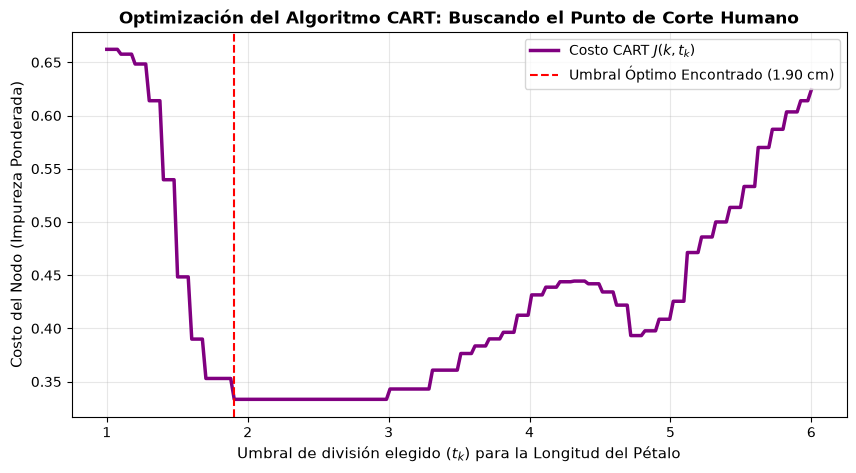

El algoritmo CART seleccionará el umbral: 1.90 cm con un costo mínimo de: 0.3333


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 1. Cargar datos
iris = load_iris()
X_petal_length = iris.data[:, 2] # Tomamos solo la longitud del pétalo
y = iris.target

# Función auxiliar para calcular la impureza de Gini de un subconjunto
def calcular_gini(y_subset):
    m_sub = len(y_subset)
    if m_sub == 0:
        return 0
    proporciones = [np.sum(y_subset == c) / m_sub for c in np.unique(y)]
    return 1 - np.sum([p**2 for p in proporciones])

# Función de Costo CART (Ecuación 5-2)
def funcion_costo_cart(X, y, umbral):
    m = len(y)
    
    # Dividir el dataset según el umbral
    izq_mask = X <= umbral
    der_mask = X > umbral
    
    y_izq, y_der = y[izq_mask], y[der_mask]
    m_izq, m_der = len(y_izq), len(y_der)
    
    # Calcular las impurezas individuales
    gini_izq = calcular_gini(y_izq)
    gini_der = calcular_gini(y_der)
    
    # Costo ponderado (Ecuación 5-2 corregida)
    costo = (m_izq / m) * gini_izq + (m_der / m) * gini_der
    return costo

# 2. Probar múltiples umbrales posibles (desde 1.0cm hasta 6.0cm)
umbrales_posibles = np.linspace(1.0, 6.0, 200)
costos = [funcion_costo_cart(X_petal_length, y, t) for t in umbrales_posibles]

# Encontrar el umbral que minimiza el costo de forma matemática
mejor_umbral = umbrales_posibles[np.argmin(costos)]
costo_minimo = np.min(costos)

# 3. Graficar la Función de Costo CART
plt.figure(figsize=(10, 5))
plt.plot(umbrales_posibles, costos, color="purple", linewidth=2.5, label="Costo CART $J(k, t_k)$")
plt.axvline(x=mejor_umbral, color="red", linestyle="--", label=f"Umbral Óptimo Encontrado ({mejor_umbral:.2f} cm)")

plt.title("Optimización del Algoritmo CART: Buscando el Punto de Corte Humano", fontsize=12, fontweight='bold')
plt.xlabel("Umbral de división elegido ($t_k$) para la Longitud del Pétalo", fontsize=11)
plt.ylabel("Costo del Nodo (Impureza Ponderada)", fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(r"C:\Users\marco\Downloads\costo_cart.png", dpi=300)
plt.show()

print(f"El algoritmo CART seleccionará el umbral: {mejor_umbral:.2f} cm con un costo mínimo de: {costo_minimo:.4f}")

### Script 2: El Efecto "Codicioso" (*Greedy*) vs Restricciones

Los árboles de decisión seguirán dividiendo los datos de forma codiciosa hasta que el costo sea cero (sobreajustando el modelo). 

El siguiente script te permite comparar visualmente cómo las restricciones como `min_samples_leaf` detienen de forma segura al algoritmo CART para evitar que memorice el dataset de entrenamiento de forma descontrolada.



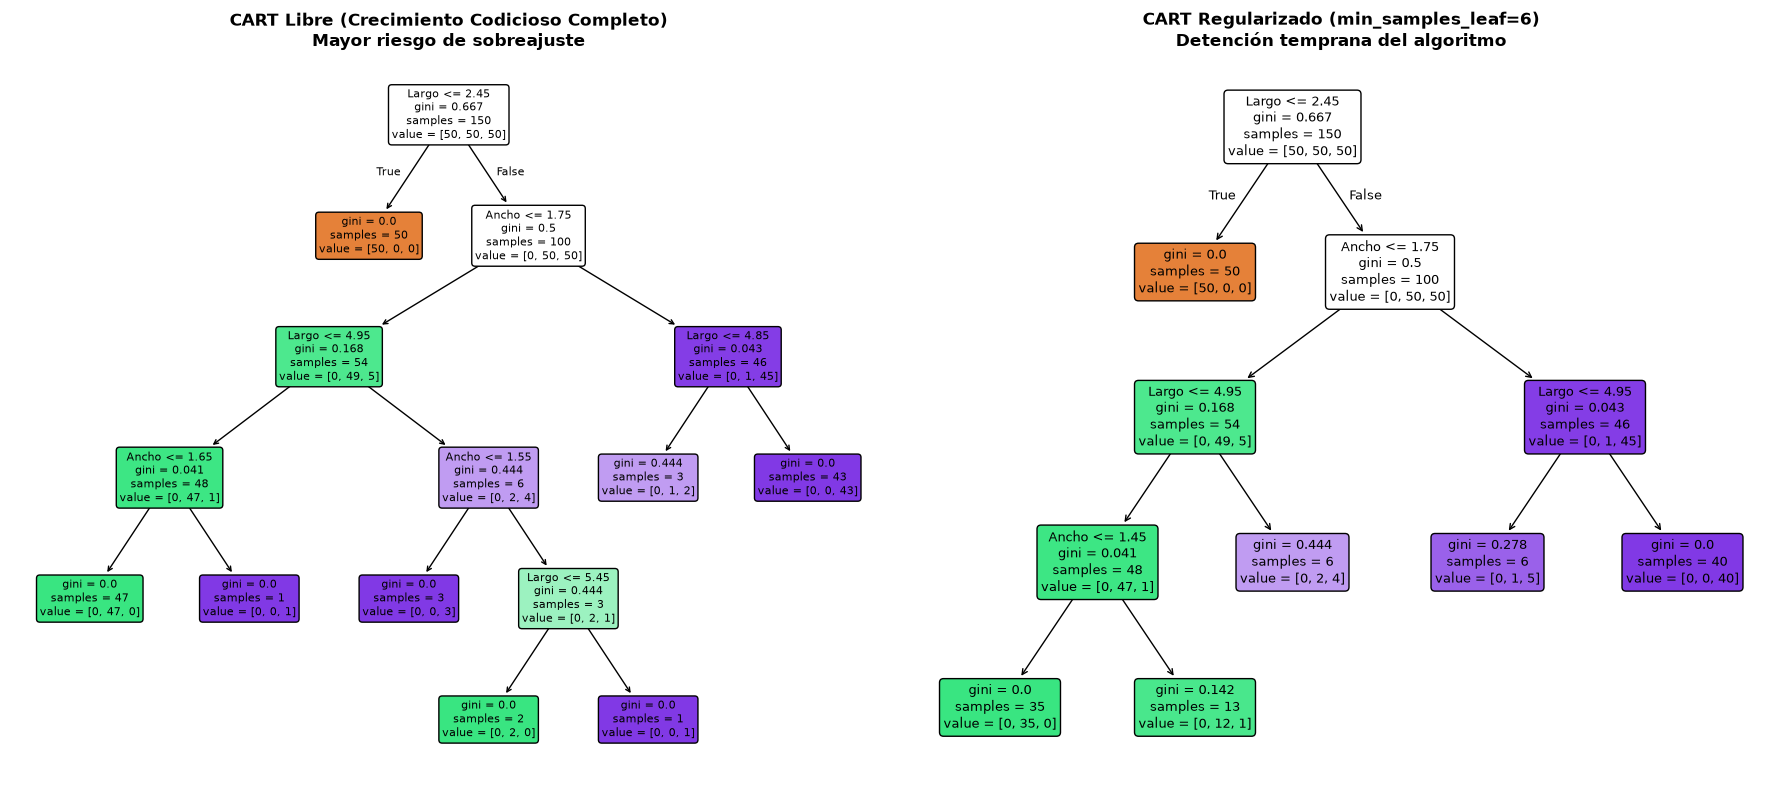

In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

iris = load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

# Árbol 1: Algoritmo CART sin frenos (tiende al sobreajuste si no se limita la profundidad)
tree_sin_restriccion = DecisionTreeClassifier(random_state=42) # max_depth=None
tree_sin_restriccion.fit(X, y)

# Árbol 2: Algoritmo CART controlado (Regularizado)
tree_con_restriccion = DecisionTreeClassifier(min_samples_leaf=6, random_state=42)
tree_con_restriccion.fit(X, y)

# Graficar ambos lados para comparar la estructura del algoritmo
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Lado izquierdo
plot_tree(tree_sin_restriccion, ax=axes[0], filled=True, rounded=True, feature_names=["Largo", "Ancho"])
axes[0].set_title("CART Libre (Crecimiento Codicioso Completo)\nMayor riesgo de sobreajuste", fontsize=12, fontweight='bold')

# Lado derecho
plot_tree(tree_con_restriccion, ax=axes[1], filled=True, rounded=True, feature_names=["Largo", "Ancho"])
axes[1].set_title("CART Regularizado (min_samples_leaf=6)\nDetención temprana del algoritmo", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\iris_decision_trees.png", dpi=300)
plt.show()
